# Project 2 - Hospital Bed Simulation
Student id: `s214985`



rules:

- Ward A patients are relocated if Ward A is full.
- Ward B patients first try Ward B, then overflow to Ward A, and are relocated only if both are full.
- Ward C patients are relocated if Ward C is full.



## 1. simulation - discrete event



In [1]:
import heapq
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

BASE_SEED = 1
HORIZON_DAYS = 365.0

N_BASELINE = 120
N_SHORTLIST = 60
N_COMPARISON = 100
TOP_CANDIDATES = 10

In [2]:
def rate_ward_a(t: float) -> float:
    return max(0.0, -(t**2) / 3650.0 + t / 10.0)


def rate_ward_b(t: float) -> float:
    return 0.2 * rate_ward_a(t)


def lognormal_from_mean_sd(mean: float, sd: float) -> dict:
    sigma2 = np.log(1.0 + (sd**2) / (mean**2))
    return {
        "dist": "lognormal",
        "mu": np.log(mean) - 0.5 * sigma2,
        "sigma": np.sqrt(sigma2),
        "mean": mean,
        "sd": sd,
    }


DEFAULT_ARRIVAL_SPECS = {
    "A": {
        "kind": "nonhomogeneous_midpoint",
        "rate_fn": rate_ward_a,
    },
    "B": {
        "kind": "nonhomogeneous_midpoint",
        "rate_fn": rate_ward_b,
    },
    "C": {"kind": "homogeneous", "rate": 6.0},
}

DEFAULT_LOS_SPECS = {
    "A": lognormal_from_mean_sd(8.0, 8.0),
    "B": lognormal_from_mean_sd(12.0, 12.0),
    "C": lognormal_from_mean_sd(10.0, 10.0),
}


def to_exponential_specs(los_specs: dict) -> dict:
    return {
        ward: {"dist": "exponential", "mean": spec["mean"]}
        for ward, spec in los_specs.items()
    }


def sample_arrivals(spec: dict, horizon: float, rng: np.random.Generator) -> list[float]:
    if spec["kind"] == "homogeneous":
        t = 0.0
        times = []
        while True:
            t += rng.exponential(1.0 / spec["rate"])
            if t > horizon:
                break
            times.append(t)
        return times

    if spec["kind"] == "nonhomogeneous_midpoint":
        times = []
        day_start = 0.0

        # Daily midpoint approximation: keep the rate constant within each day.
        while day_start < horizon:
            day_end = min(day_start + 1.0, horizon)
            interval_length = day_end - day_start
            midpoint = day_start + 0.5 * interval_length
            expected_arrivals = spec["rate_fn"](midpoint) * interval_length
            n_arrivals = rng.poisson(expected_arrivals)

            if n_arrivals > 0:
                times.extend(day_start + rng.random(n_arrivals) * interval_length)

            day_start = day_end

        times.sort()
        return times

    raise ValueError(f"Unsupported arrival specification: {spec['kind']}")


def sample_los(spec: dict, rng: np.random.Generator) -> float:
    if spec["dist"] == "lognormal":
        return rng.lognormal(spec["mu"], spec["sigma"])
    if spec["dist"] == "exponential":
        return rng.exponential(spec["mean"])
    raise ValueError(f"Unsupported LOS distribution: {spec['dist']}")


def replication_seeds(n_replications: int, base_seed: int = BASE_SEED) -> list[int]:
    children = np.random.SeedSequence(base_seed).spawn(n_replications)
    return [int(child.generate_state(1)[0]) for child in children]


def scale_allocation(reference_beds: dict, total_beds: int) -> dict:
    reference = np.array([reference_beds["A"], reference_beds["B"], reference_beds["C"]], dtype=float)
    raw = reference / reference.sum() * total_beds
    scaled = np.maximum(np.floor(raw).astype(int), 1)

    diff = total_beds - scaled.sum()
    fractions = raw - np.floor(raw)
    order = np.argsort(-fractions)

    i = 0
    while diff > 0:
        scaled[order[i % 3]] += 1
        diff -= 1
        i += 1

    while diff < 0:
        idx = int(np.argmax(scaled))
        if scaled[idx] > 1:
            scaled[idx] -= 1
            diff += 1
        else:
            break

    return {"A": int(scaled[0]), "B": int(scaled[1]), "C": int(scaled[2])}

In [3]:
def simulate_hospital_year(
    beds: dict,
    los_specs: dict | None = None,
    arrival_specs: dict | None = None,
    horizon: float = HORIZON_DAYS,
    seed: int = BASE_SEED,
) -> dict:
    beds = dict(beds)
    los_specs = los_specs or DEFAULT_LOS_SPECS
    arrival_specs = arrival_specs or DEFAULT_ARRIVAL_SPECS
    rng = np.random.default_rng(seed)

    event_heap = []
    for patient_type, spec in arrival_specs.items():
        for arrival_time in sample_arrivals(spec, horizon, rng):
            event_heap.append((arrival_time, 1, "arrival", patient_type))
    heapq.heapify(event_heap)

    departures_by_ward = {"A": [], "B": [], "C": []}
    occupied = {"A": 0, "B": 0, "C": 0}
    occupied_bed_time = {"A": 0.0, "B": 0.0, "C": 0.0}
    arrivals = {"A": 0, "B": 0, "C": 0}
    primary_full = {"A": 0, "B": 0, "C": 0}
    relocated = {"A": 0, "B": 0, "C": 0}
    overflow_b_to_a = 0

    last_time = 0.0

    while event_heap:
        current_time, _, event_type, label = heapq.heappop(event_heap)
        if current_time > horizon:
            break

        dt = current_time - last_time
        for ward in occupied:
            occupied_bed_time[ward] += occupied[ward] * dt
        last_time = current_time

        if event_type == "departure":
            heapq.heappop(departures_by_ward[label])
            occupied[label] -= 1
            continue

        patient_type = label
        arrivals[patient_type] += 1

        if patient_type == "A":
            if occupied["A"] >= beds["A"]:
                primary_full["A"] += 1
                relocated["A"] += 1
            else:
                departure_time = current_time + sample_los(los_specs["A"], rng)
                heapq.heappush(event_heap, (departure_time, 0, "departure", "A"))
                heapq.heappush(departures_by_ward["A"], departure_time)
                occupied["A"] += 1

        elif patient_type == "B":
            if occupied["B"] >= beds["B"]:
                primary_full["B"] += 1

            if occupied["B"] < beds["B"]:
                target_ward = "B"
            elif occupied["A"] < beds["A"]:
                target_ward = "A"
                overflow_b_to_a += 1
            else:
                relocated["B"] += 1
                continue

            departure_time = current_time + sample_los(los_specs["B"], rng)
            heapq.heappush(event_heap, (departure_time, 0, "departure", target_ward))
            heapq.heappush(departures_by_ward[target_ward], departure_time)
            occupied[target_ward] += 1

        else:
            if occupied["C"] >= beds["C"]:
                primary_full["C"] += 1
                relocated["C"] += 1
            else:
                departure_time = current_time + sample_los(los_specs["C"], rng)
                heapq.heappush(event_heap, (departure_time, 0, "departure", "C"))
                heapq.heappush(departures_by_ward["C"], departure_time)
                occupied["C"] += 1

    dt = horizon - last_time
    for ward in occupied:
        occupied_bed_time[ward] += occupied[ward] * dt

    utilization_a = occupied_bed_time["A"] / (beds["A"] * horizon)
    utilization_b = occupied_bed_time["B"] / (beds["B"] * horizon)
    utilization_c = occupied_bed_time["C"] / (beds["C"] * horizon)

    return {
        "arrivals_A": arrivals["A"],
        "arrivals_B": arrivals["B"],
        "arrivals_C": arrivals["C"],
        "primary_full_prob_A": primary_full["A"] / arrivals["A"],
        "primary_full_prob_B": primary_full["B"] / arrivals["B"],
        "primary_full_prob_C": primary_full["C"] / arrivals["C"],
        "relocated_A": relocated["A"],
        "relocated_B": relocated["B"],
        "relocated_C": relocated["C"],
        "relocated_total": sum(relocated.values()),
        "utilization_A": utilization_a,
        "utilization_B": utilization_b,
        "utilization_C": utilization_c,
        "weighted_mean_utilization": (
            beds["A"] * utilization_a
            + beds["B"] * utilization_b
            + beds["C"] * utilization_c
        ) / sum(beds.values()),
        "overflow_B_to_A": overflow_b_to_a,
    }


def run_replications(
    beds: dict,
    los_specs: dict | None = None,
    arrival_specs: dict | None = None,
    n_replications: int = 100,
    base_seed: int = BASE_SEED,
) -> pd.DataFrame:
    seeds = replication_seeds(n_replications, base_seed=base_seed)
    records = [
        simulate_hospital_year(
            beds=beds,
            los_specs=los_specs,
            arrival_specs=arrival_specs,
            seed=seed,
        )
        for seed in seeds
    ]
    return pd.DataFrame(records)


def confidence_interval(values: pd.Series, z_value: float = 1.96) -> tuple[float, float, float]:
    mean = float(values.mean())
    half_width = float(z_value * values.std(ddof=1) / np.sqrt(len(values)))
    return mean, mean - half_width, mean + half_width


def summarise_metrics(frame: pd.DataFrame, metric_map: dict, decimals: int = 4) -> pd.DataFrame:
    rows = []
    for label, column in metric_map.items():
        mean, ci_low, ci_high = confidence_interval(frame[column])
        rows.append(
            {
                "metric": label,
                "mean": mean,
                "ci_low": ci_low,
                "ci_high": ci_high,
            }
        )
    return pd.DataFrame(rows).set_index("metric").round(decimals)


def screen_bed_allocations(
    total_beds: int = 75,
    min_beds: dict | None = None,
    seed: int = BASE_SEED,
) -> pd.DataFrame:
    min_beds = min_beds or {"A": 1, "B": 1, "C": 1}
    rows = []

    for beds_a in range(min_beds["A"], total_beds - min_beds["B"] - min_beds["C"] + 1):
        max_b = total_beds - beds_a - min_beds["C"]
        for beds_b in range(min_beds["B"], max_b + 1):
            beds_c = total_beds - beds_a - beds_b
            if beds_c < min_beds["C"]:
                continue
            result = simulate_hospital_year(
                beds={"A": beds_a, "B": beds_b, "C": beds_c},
                seed=seed,
            )
            rows.append(
                {
                    "A": beds_a,
                    "B": beds_b,
                    "C": beds_c,
                    "screen_relocated_total": result["relocated_total"],
                    "utilization_A": result["utilization_A"],
                    "utilization_B": result["utilization_B"],
                    "utilization_C": result["utilization_C"],
                    "weighted_mean_utilization": result["weighted_mean_utilization"],
                }
            )

    return pd.DataFrame(rows)

,single_run_output
arrivals_A,2203.0
arrivals_B,450.0
arrivals_C,2128.0
relocated_A,1127.0
relocated_B,135.0
relocated_C,806.0
relocated_total,2068.0


Building a 75-bed allocation map with seed 1...


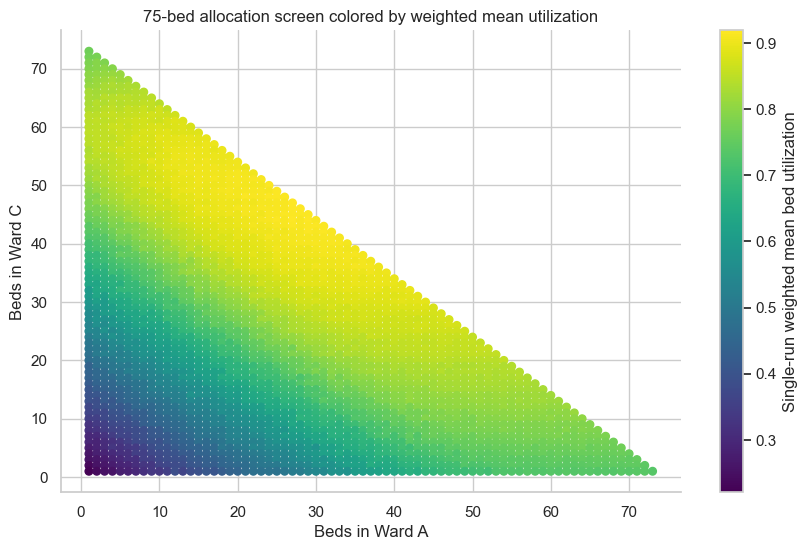

In [4]:
baseline_beds = {"A": 30, "B": 9, "C": 36}

single_run_example = pd.Series(simulate_hospital_year(baseline_beds, seed=BASE_SEED))
display(single_run_example[[
    "arrivals_A",
    "arrivals_B",
    "arrivals_C",
    "relocated_A",
    "relocated_B",
    "relocated_C",
    "relocated_total",
]].to_frame("single_run_output"))

print("Building a 75-bed allocation map with seed 1...")
screen_results = screen_bed_allocations(total_beds=75, seed=BASE_SEED)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    screen_results["A"],
    screen_results["C"],
    c=screen_results["weighted_mean_utilization"],
    cmap="viridis",
    s=30,
)
plt.colorbar(scatter, label="Single-run weighted mean bed utilization")
plt.xlabel("Beds in Ward A")
plt.ylabel("Beds in Ward C")
plt.title("75-bed allocation screen colored by weighted mean utilization")
plt.show()

# Example of how the model can be re-used with dynamic inputs:
# alternative_beds = {"A": 28, "B": 4, "C": 43}
# alternative_los = dict(DEFAULT_LOS_SPECS)
# alternative_los["A"] = lognormal_from_mean_sd(mean=7.0, sd=6.0)
# alternative_runs = run_replications(alternative_beds, los_specs=alternative_los, n_replications=50)

## 2.  performance measures



In [5]:
baseline_runs = run_replications(baseline_beds, n_replications=N_BASELINE)

blocking_summary = summarise_metrics(
    baseline_runs,
    {
        "Ward A full on A-arrival": "primary_full_prob_A",
        "Ward B full on B-arrival": "primary_full_prob_B",
        "Ward C full on C-arrival": "primary_full_prob_C",
    },
    decimals=4,
)

relocation_summary = summarise_metrics(
    baseline_runs,
    {
        "Relocated A-patients": "relocated_A",
        "Relocated B-patients": "relocated_B",
        "Relocated C-patients": "relocated_C",
        "Relocated patients in total": "relocated_total",
    },
    decimals=1,
)

utilization_summary = summarise_metrics(
    baseline_runs,
    {
        "Ward A utilization": "utilization_A",
        "Ward B utilization": "utilization_B",
        "Ward C utilization": "utilization_C",
        "ICU overflow from B to A": "overflow_B_to_A",
    },
    decimals=4,
)

display(blocking_summary)
display(relocation_summary)
display(utilization_summary)

,mean,ci_low,ci_high
metric,,,
Ward A full on A-arrival,0.5255,0.5224,0.5287
Ward B full on B-arrival,0.5046,0.4982,0.5110
Ward C full on C-arrival,0.4098,0.4060,0.4136


,mean,ci_low,ci_high
metric,,,
Relocated A-patients,1166.0,1156.0,1176.1
Relocated B-patients,135.0,131.9,138.1
Relocated C-patients,897.9,886.9,908.8
Relocated patients in total,2198.9,2182.5,2215.4


,mean,ci_low,ci_high
metric,,,
Ward A utilization,0.8575,0.8557,0.8593
Ward B utilization,0.7997,0.7957,0.8037
Ward C utilization,0.9556,0.9549,0.9564
ICU overflow from B to A,89.2667,87.3150,91.2184


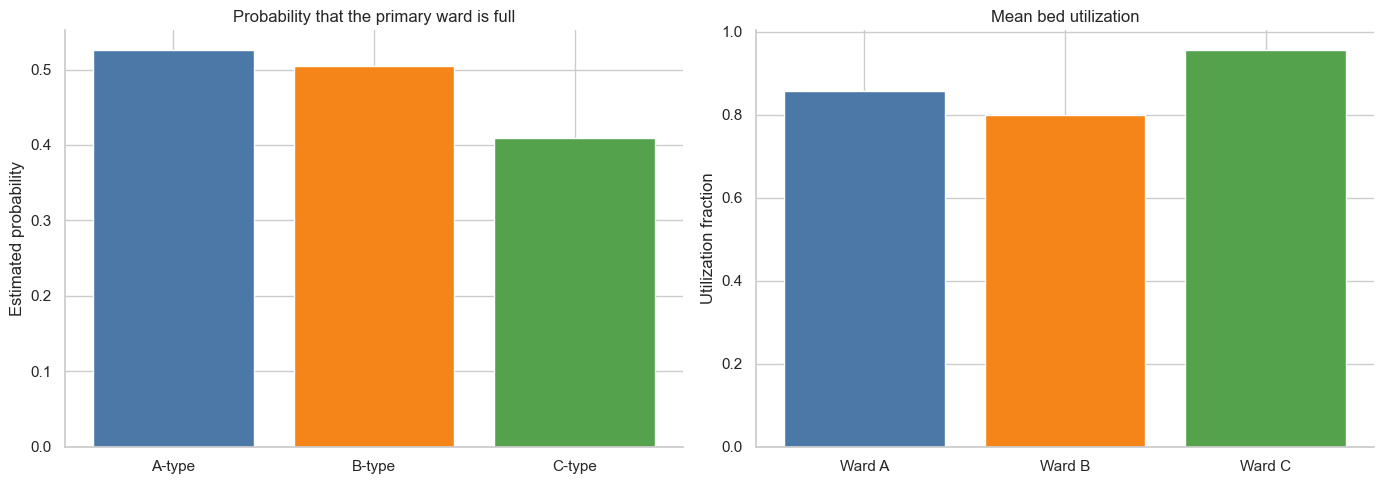

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    ["A-type", "B-type", "C-type"],
    [
        baseline_runs["primary_full_prob_A"].mean(),
        baseline_runs["primary_full_prob_B"].mean(),
        baseline_runs["primary_full_prob_C"].mean(),
    ],
    color=["#4C78A8", "#F58518", "#54A24B"],
)
axes[0].set_title("Probability that the primary ward is full")
axes[0].set_ylabel("Estimated probability")

axes[1].bar(
    ["Ward A", "Ward B", "Ward C"],
    [
        baseline_runs["utilization_A"].mean(),
        baseline_runs["utilization_B"].mean(),
        baseline_runs["utilization_C"].mean(),
    ],
    color=["#4C78A8", "#F58518", "#54A24B"],
)
axes[1].set_title("Mean bed utilization")
axes[1].set_ylabel("Utilization fraction")

plt.tight_layout()
plt.show()

The baseline results already indicate a very stressed system. With only 75 beds in total, the model spends most of the year near capacity, especially in Ward C, so relocations and bed utilization are the most meaningful congestion measures.

## 3. Sensitivity



,A,B,C,screen_relocated_total,utilization_A,utilization_B,utilization_C,weighted_mean_utilization
0,33,1,41,2006,0.876772,0.916549,0.937923,0.910732
1,30,2,43,2008,0.886027,0.886760,0.937442,0.915524
2,32,1,42,2012,0.882147,0.917751,0.937511,0.913626
3,30,1,44,2014,0.886939,0.895982,0.932555,0.913821
4,29,3,43,2015,0.891354,0.857648,0.937411,0.916411
5,31,2,42,2015,0.878211,0.885676,0.943689,0.915078
6,31,1,43,2016,0.884007,0.933021,0.935565,0.914221
7,29,2,44,2018,0.893355,0.901501,0.934184,0.917525
8,37,1,37,2018,0.859411,0.888417,0.948130,0.903566
9,31,3,41,2019,0.880516,0.871804,0.942063,0.913813


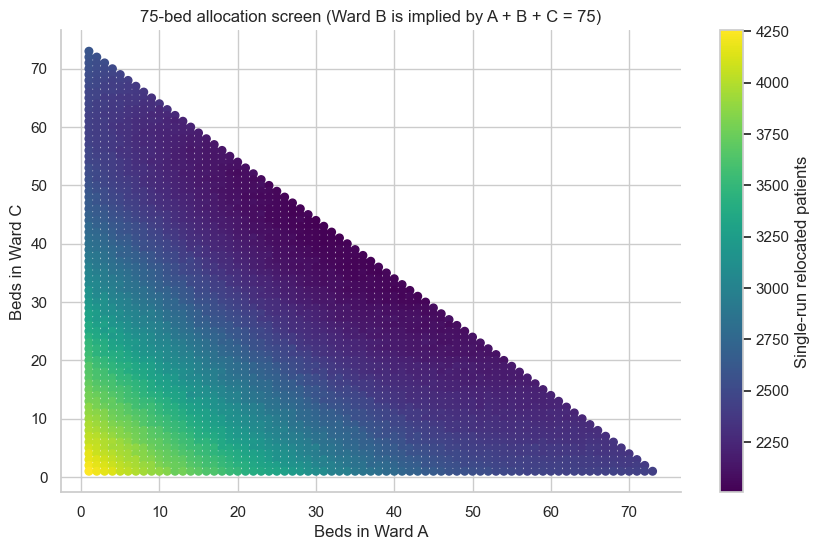

In [7]:
shortlist = screen_results.nsmallest(TOP_CANDIDATES, "screen_relocated_total").reset_index(drop=True)

display(shortlist)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    screen_results["A"],
    screen_results["C"],
    c=screen_results["screen_relocated_total"],
    cmap="viridis",
    s=30,
)
plt.colorbar(scatter, label="Single-run relocated patients")
plt.xlabel("Beds in Ward A")
plt.ylabel("Beds in Ward C")
plt.title("75-bed allocation screen (Ward B is implied by A + B + C = 75)")
plt.show()

In [8]:
candidate_rows = []
for row in shortlist.itertuples(index=False):
    beds = {"A": row.A, "B": row.B, "C": row.C}
    runs = run_replications(beds, n_replications=N_SHORTLIST)
    candidate_rows.append(
        {
            "A": row.A,
            "B": row.B,
            "C": row.C,
            "mean_relocated_total": runs["relocated_total"].mean(),
            "mean_full_prob_A": runs["primary_full_prob_A"].mean(),
            "mean_full_prob_B": runs["primary_full_prob_B"].mean(),
            "mean_full_prob_C": runs["primary_full_prob_C"].mean(),
            "mean_util_A": runs["utilization_A"].mean(),
            "mean_util_B": runs["utilization_B"].mean(),
            "mean_util_C": runs["utilization_C"].mean(),
        }
    )

candidate_summary = pd.DataFrame(candidate_rows).sort_values("mean_relocated_total").reset_index(drop=True)
best_beds = candidate_summary.loc[0, ["A", "B", "C"]].astype(int).to_dict()

display(candidate_summary.round(4))
print("Best 75-bed allocation under the relocation objective:", best_beds)

,A,B,C,mean_relocated_total,mean_full_prob_A,mean_full_prob_B,mean_full_prob_C,mean_util_A,mean_util_B,mean_util_C
0,33,1,41,2136.5167,0.5332,0.9379,0.3311,0.8710,0.8918,0.9474
1,32,1,42,2137.4000,0.5456,0.9373,0.3161,0.8736,0.8927,0.9456
2,30,1,44,2139.5333,0.5687,0.9370,0.2894,0.8791,0.8921,0.9418
3,31,1,43,2139.6000,0.5585,0.9396,0.3025,0.8769,0.8942,0.9435
4,31,2,42,2143.3500,0.5501,0.8783,0.3187,0.8722,0.8799,0.9457
5,37,1,37,2143.5667,0.4831,0.9358,0.3951,0.8579,0.8917,0.9538
6,30,2,43,2144.4833,0.5651,0.8775,0.3019,0.8758,0.8798,0.9437
7,29,2,44,2145.4500,0.5754,0.8779,0.2892,0.8788,0.8827,0.9418
8,31,3,41,2148.1500,0.5434,0.8212,0.3337,0.8699,0.8683,0.9475
9,29,3,43,2150.1500,0.5696,0.8142,0.3046,0.8750,0.8670,0.9440


Best 75-bed allocation under the relocation objective: {'A': 33, 'B': 1, 'C': 41}


A useful modeling insight appears here: minimizing total relocations alone pushes Ward B toward the minimum feasible size, because Ward B patients can spill over into Ward A, while Ward C patients are lost immediately when Ward C is full. If ICU access should be protected more strongly, the objective function should penalize Ward B blocking or Ward B relocations more heavily.

,scenario,los_distribution,relocated_total,full_prob_A,full_prob_B,full_prob_C,util_A,util_B,util_C
0,Baseline,Lognormal,2195.21,0.5253,0.5039,0.4089,0.8568,0.7992,0.9554
1,Baseline,Exponential,2205.09,0.5283,0.5052,0.4103,0.8562,0.7959,0.9546
2,Near-optimal,Lognormal,2134.32,0.5348,0.9384,0.3298,0.8691,0.8940,0.9469
3,Near-optimal,Exponential,2143.30,0.5344,0.9374,0.3348,0.8688,0.8956,0.9468


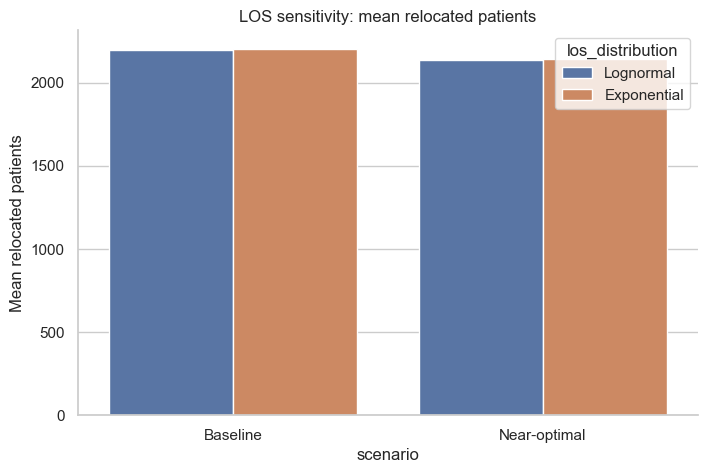

In [9]:
los_comparison_rows = []
exponential_los = to_exponential_specs(DEFAULT_LOS_SPECS)

for scenario_name, beds in [("Baseline", baseline_beds), ("Near-optimal", best_beds)]:
    for los_name, los_specs in [("Lognormal", DEFAULT_LOS_SPECS), ("Exponential", exponential_los)]:
        runs = run_replications(beds, los_specs=los_specs, n_replications=N_COMPARISON)
        los_comparison_rows.append(
            {
                "scenario": scenario_name,
                "los_distribution": los_name,
                "relocated_total": runs["relocated_total"].mean(),
                "full_prob_A": runs["primary_full_prob_A"].mean(),
                "full_prob_B": runs["primary_full_prob_B"].mean(),
                "full_prob_C": runs["primary_full_prob_C"].mean(),
                "util_A": runs["utilization_A"].mean(),
                "util_B": runs["utilization_B"].mean(),
                "util_C": runs["utilization_C"].mean(),
            }
        )

los_comparison = pd.DataFrame(los_comparison_rows).round(4)
display(los_comparison)

plt.figure(figsize=(8, 5))
sns.barplot(data=los_comparison, x="scenario", y="relocated_total", hue="los_distribution")
plt.title("LOS sensitivity: mean relocated patients")
plt.ylabel("Mean relocated patients")
plt.show()

,total_beds,A,B,C,relocated_total,util_A,util_B,util_C
0,60,26,2,32,2647.53,0.8866,0.8806,0.9606
1,75,33,1,41,2134.32,0.8691,0.8940,0.9469
2,80,35,1,44,1972.46,0.8632,0.8922,0.9419
3,100,44,1,55,1378.46,0.8354,0.8920,0.9083


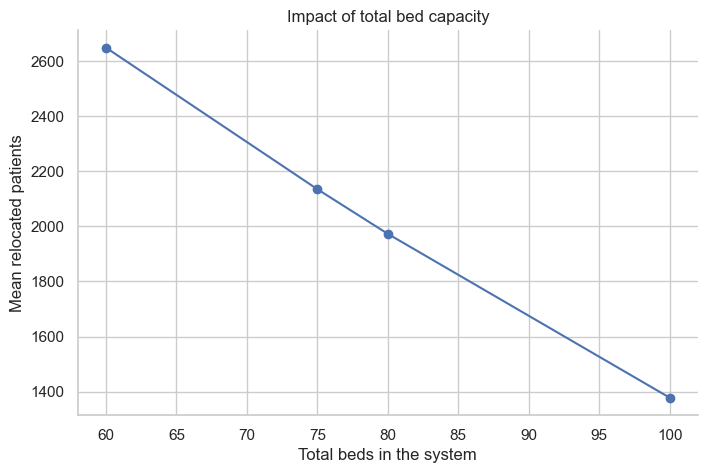

In [10]:
capacity_rows = []
for total_beds in [60, 75, 80, 100]:
    scaled_beds = scale_allocation(best_beds, total_beds)
    runs = run_replications(scaled_beds, n_replications=N_COMPARISON)
    capacity_rows.append(
        {
            "total_beds": total_beds,
            "A": scaled_beds["A"],
            "B": scaled_beds["B"],
            "C": scaled_beds["C"],
            "relocated_total": runs["relocated_total"].mean(),
            "util_A": runs["utilization_A"].mean(),
            "util_B": runs["utilization_B"].mean(),
            "util_C": runs["utilization_C"].mean(),
        }
    )

capacity_sensitivity = pd.DataFrame(capacity_rows).round(4)
display(capacity_sensitivity)

plt.figure(figsize=(8, 5))
plt.plot(capacity_sensitivity["total_beds"], capacity_sensitivity["relocated_total"], marker="o")
plt.title("Impact of total bed capacity")
plt.xlabel("Total beds in the system")
plt.ylabel("Mean relocated patients")
plt.show()